# K-Center From Scratch

This Jupyter Notebook provides a detailed, step-by-step guide on implementing the K-Center clustering algorithm from scratch. It covers the following key areas:
- Sample data points
- Select one initial cluster center
- Update distance of each point to its closest center
- Add a new cluster center
- Show clutering results

In [1]:
import random
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(cmap.N)]

mpl.rcParams["font.size"] = 24
mpl.rcParams["lines.linewidth"] = 2

seed = 0
random.seed(seed)
np.random.seed(seed)
n_samples = 10
markersize = 100

## Sample data points

In [2]:
m1 = [1, 1]
cov1 = [[1, 0], [0, 1]]
s1 = np.random.multivariate_normal(m1, cov1, 5)

m2 = [-1, -1]
cov2 = [[1, -0.5], [-0.5, 1]]
s2 = np.random.multivariate_normal(m2, cov2, 5)

samples = np.concat([s1, s2])
np.random.shuffle(samples)

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

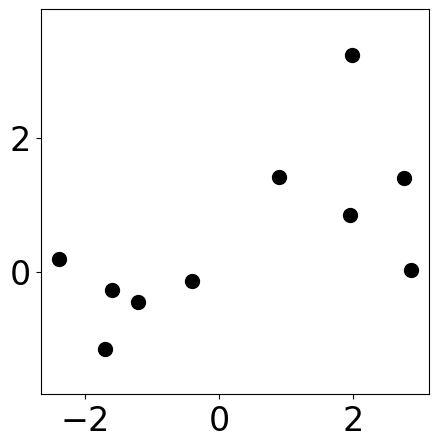

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=markersize, color="k")
# plt.axis("off")
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.axis("equal")

## Select one initial cluster center

In [4]:
# initialize 1st center
centers = [0, ]

# initialize distance matrix
losses = []
n_points = samples.shape[0]
distances = np.full(n_points, np.inf)

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

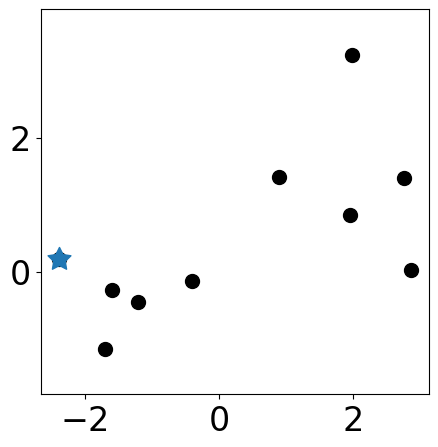

In [5]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=markersize, color="k")
plt.scatter(samples[centers][:,0], samples[centers][:, 1],
            s=markersize*3, c=colors[:len(centers)], marker=(5, 1))
plt.axis("equal")

## Update distance of each point to its closest center

In [6]:
last_center = centers[-1]
for i in range(n_points):
    new_dist = np.linalg.norm(samples[i]-samples[last_center])
    distances[i] = min(distances[i], new_dist)

Visualize Distances

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

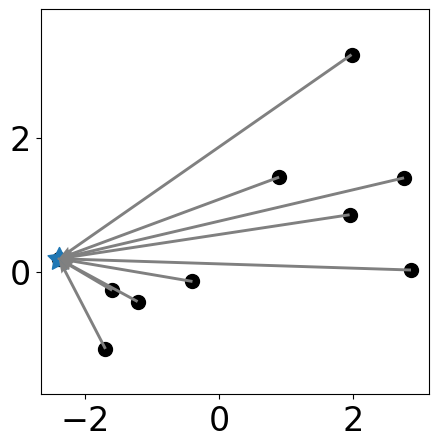

In [7]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color="k")

# old centers
plt.scatter(samples[centers][:,0], samples[centers][:, 1], \
            s=markersize*3, c=colors[:len(centers)], marker=(5, 1))

# assign predicted labels
labels = [np.argmin(np.sum((samples[i, :]-samples[centers])**2, axis=1)) \
    for i in range(samples.shape[0])]

# add assignment vectors
for i in range(samples.shape[0]):
    to_point = samples[centers[labels[i]]]
    from_point = samples[i]
    plt.quiver(from_point[0], from_point[1],
               to_point[0]-from_point[0], to_point[1]-from_point[1],
               angles="xy", scale_units="xy", scale=1, color="gray",
               linewidth=1.5, linestyle="--")

plt.axis("equal")

## Add a new cluster center

In [8]:
## pick the point with the maximum distance as next center
next_center = np.argmax(distances)
centers.append(next_center)

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

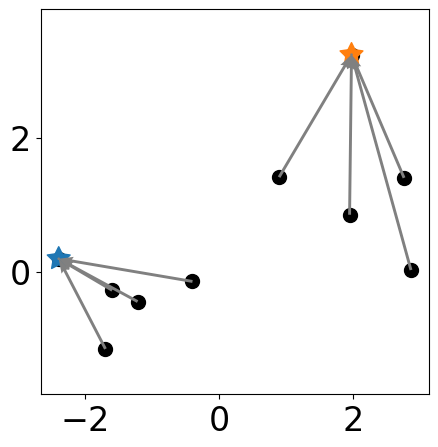

In [9]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color="k")

# new centers
plt.scatter(samples[centers][:,0], samples[centers][:, 1], \
            s=markersize*3, c=colors[:len(centers)], marker=(5, 1))

# assign predicted labels
labels = [np.argmin(np.sum((samples[i, :]-samples[centers])**2, axis=1)) \
    for i in range(samples.shape[0])]

# add assignment vectors
for i in range(samples.shape[0]):
    to_point = samples[centers[labels[i]]]
    from_point = samples[i]
    plt.quiver(from_point[0], from_point[1],
               to_point[0]-from_point[0], to_point[1]-from_point[1],
               angles="xy", scale_units="xy", scale=1, color="gray",
               linewidth=1.5, linestyle="--")

plt.axis("equal")

## Show clutering results

In [10]:
def k_center(points, k):
    losses = []
    n_points = points.shape[0]
    centers = []
    distances = np.full(n_points, np.inf)

    for j in range(0, k):
        if j == 0:
            centers = [0]

        for i in range(n_points):
            new_dist = np.linalg.norm(points[i]-points[centers[-1]])
            distances[i] = min(distances[i], new_dist)

        if j>=1:
            next_center = np.argmax(distances)
            centers.append(next_center)

        losses.append(np.max(distances))

    return centers, losses

In [11]:
k = 3
new_centers, losses = k_center(samples, k)
new_centers = samples[new_centers]

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

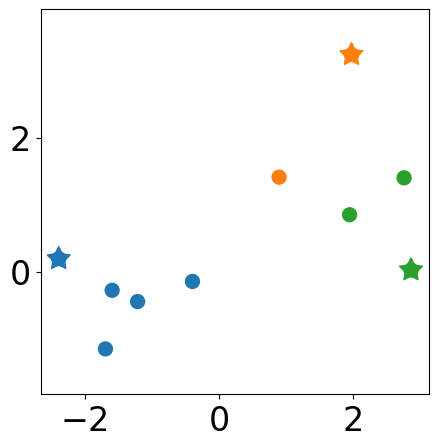

In [12]:
labels = [np.argmin(np.sum((samples[i, :]-new_centers)**2, axis=1)) for i in range(samples.shape[0])]

plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color=[colors[l] for l in labels])

# new centers
plt.scatter(new_centers[:,0], new_centers[:, 1],
            s=markersize*3, c=colors[:k], marker=(5, 1))
plt.axis("equal")